# Cleaning the Dataset

## 1. Pre knowledge on the dataset

Each two file, namely: Umi.h5, Rma.h5, contains:
• Data: complex64 array, shape (98304, 1024) = the noisy received I/Q symbol vectors
• Mods: float32 array, shape (98304, 6) = modulation label, order [BPSK, QPSK, 16QAM, 
64QAM, 256QAM, 1024QAM]
• SNRs: float32 array, shape (98304, ) = the Eb/N0 value (dB) used to generate that row
98304 = 6 modulations * 16 SNR levels * 1024 vectors.
Each file is approximately 712-713 MB.

From our previous meeting we had decided that we would use 5 modulation schemes since 1024 QAM is very unstable. Therefore, we need to take out 1024 QAM in this cleaning session.

Therefore in this .ipynb, the first task is to make sure we clean the dataset out of these.

In [1]:
DATA_DIR           = '../data/'
DATA_RAW_DIR       = DATA_DIR + 'raw/'
DATA_PROCESSED_DIR = DATA_DIR + 'processed/'

RMA_H5_DIR         = DATA_RAW_DIR + 'Rma.h5'
UMI_H5_DIR         = DATA_RAW_DIR + 'Umi.h5'
UMA_H5_DIR         = DATA_RAW_DIR + 'Uma.h5'

UMI_CLEAN_DIR = DATA_PROCESSED_DIR + 'Umi_clean.h5'
RMA_CLEAN_DIR = DATA_PROCESSED_DIR + 'Rma_clean.h5'
UMA_CLEAN_DIR = DATA_PROCESSED_DIR + 'Uma_clean.h5'

## 2. Inspect file structure

Before touching the data, confirm the actual keys, shapes, and dtypes

In [2]:
import h5py

for path in [UMI_H5_DIR, RMA_H5_DIR, UMA_H5_DIR]:

    print(f"--- {path} ---")

    with h5py.File(path, 'r') as f:

        def show(name, obj):

            if isinstance(obj, h5py.Dataset):
                print(f"  {name:10s} shape={obj.shape} dtype={obj.dtype}")

        f.visititems(show)

    print()

--- ../data/raw/Umi.h5 ---
  Data       shape=(98304, 1024) dtype=complex64
  Mods       shape=(98304, 6) dtype=float32
  SNRs       shape=(98304,) dtype=float32

--- ../data/raw/Rma.h5 ---
  Data       shape=(98304, 1024) dtype=complex64
  Mods       shape=(98304, 6) dtype=float32
  SNRs       shape=(98304,) dtype=float32

--- ../data/raw/Uma.h5 ---
  Data       shape=(98304, 1024) dtype=complex64
  Mods       shape=(98304, 6) dtype=float32
  SNRs       shape=(98304,) dtype=float32



## 3. Taking the Data In

In [3]:
with h5py.File(UMI_H5_DIR, 'r') as f:
    umi_data = f['Data'][:]
    umi_mods = f['Mods'][:]
    umi_snrs = f['SNRs'][:]

with h5py.File(RMA_H5_DIR, 'r') as f:
    rma_data = f['Data'][:]
    rma_mods = f['Mods'][:]
    rma_snrs = f['SNRs'][:]

with h5py.File(UMA_H5_DIR, 'r') as f:
    uma_data = f['Data'][:]
    uma_mods = f['Mods'][:]
    uma_snrs = f['SNRs'][:]

## 4. Verification of the 1024-QAM Column

In [4]:
for name, mods in [('Umi', umi_mods), ('Rma', rma_mods), ('Uma', uma_mods)]:

    counts = mods.sum(axis=0)
    print(f"{name} column sums: {counts}")
    
    row_sums = mods.sum(axis=1)
    print(f"{name} all rows one-hot: {(row_sums == 1).all()}")

Umi column sums: [16384. 16384. 16384. 16384. 16384. 16384.]
Umi all rows one-hot: True
Rma column sums: [16384. 16384. 16384. 16384. 16384. 16384.]
Rma all rows one-hot: True
Uma column sums: [16384. 16384. 16384. 16384. 16384. 16384.]
Uma all rows one-hot: True


## 5. Load, filter out 1024QAM, and save cleaned files

In [5]:
umi_mask = umi_mods[:, 5] == 0
rma_mask = rma_mods[:, 5] == 0
uma_mask = uma_mods[:, 5] == 0

umi_data, umi_mods, umi_snrs = umi_data[umi_mask], umi_mods[umi_mask, :5], umi_snrs[umi_mask]
rma_data, rma_mods, rma_snrs = rma_data[rma_mask], rma_mods[rma_mask, :5], rma_snrs[rma_mask]
uma_data, uma_mods, uma_snrs = uma_data[uma_mask], uma_mods[uma_mask, :5], uma_snrs[uma_mask]

print(f"Umi: {umi_mask.sum()} / {len(umi_mask)} rows kept")
print(f"Rma: {rma_mask.sum()} / {len(rma_mask)} rows kept")
print(f"Uma: {uma_mask.sum()} / {len(uma_mask)} rows kept")

Umi: 81920 / 98304 rows kept
Rma: 81920 / 98304 rows kept
Uma: 81920 / 98304 rows kept


In [6]:
with h5py.File(UMI_CLEAN_DIR, 'w') as f:
    f.create_dataset('Data', data=umi_data)
    f.create_dataset('Mods', data=umi_mods)
    f.create_dataset('SNRs', data=umi_snrs)

with h5py.File(RMA_CLEAN_DIR, 'w') as f:
    f.create_dataset('Data', data=rma_data)
    f.create_dataset('Mods', data=rma_mods)
    f.create_dataset('SNRs', data=rma_snrs)

with h5py.File(UMA_CLEAN_DIR, 'w') as f:
    f.create_dataset('Data', data=uma_data)
    f.create_dataset('Mods', data=uma_mods)
    f.create_dataset('SNRs', data=uma_snrs)

## 6. Documenting the Final Modulation Schemes

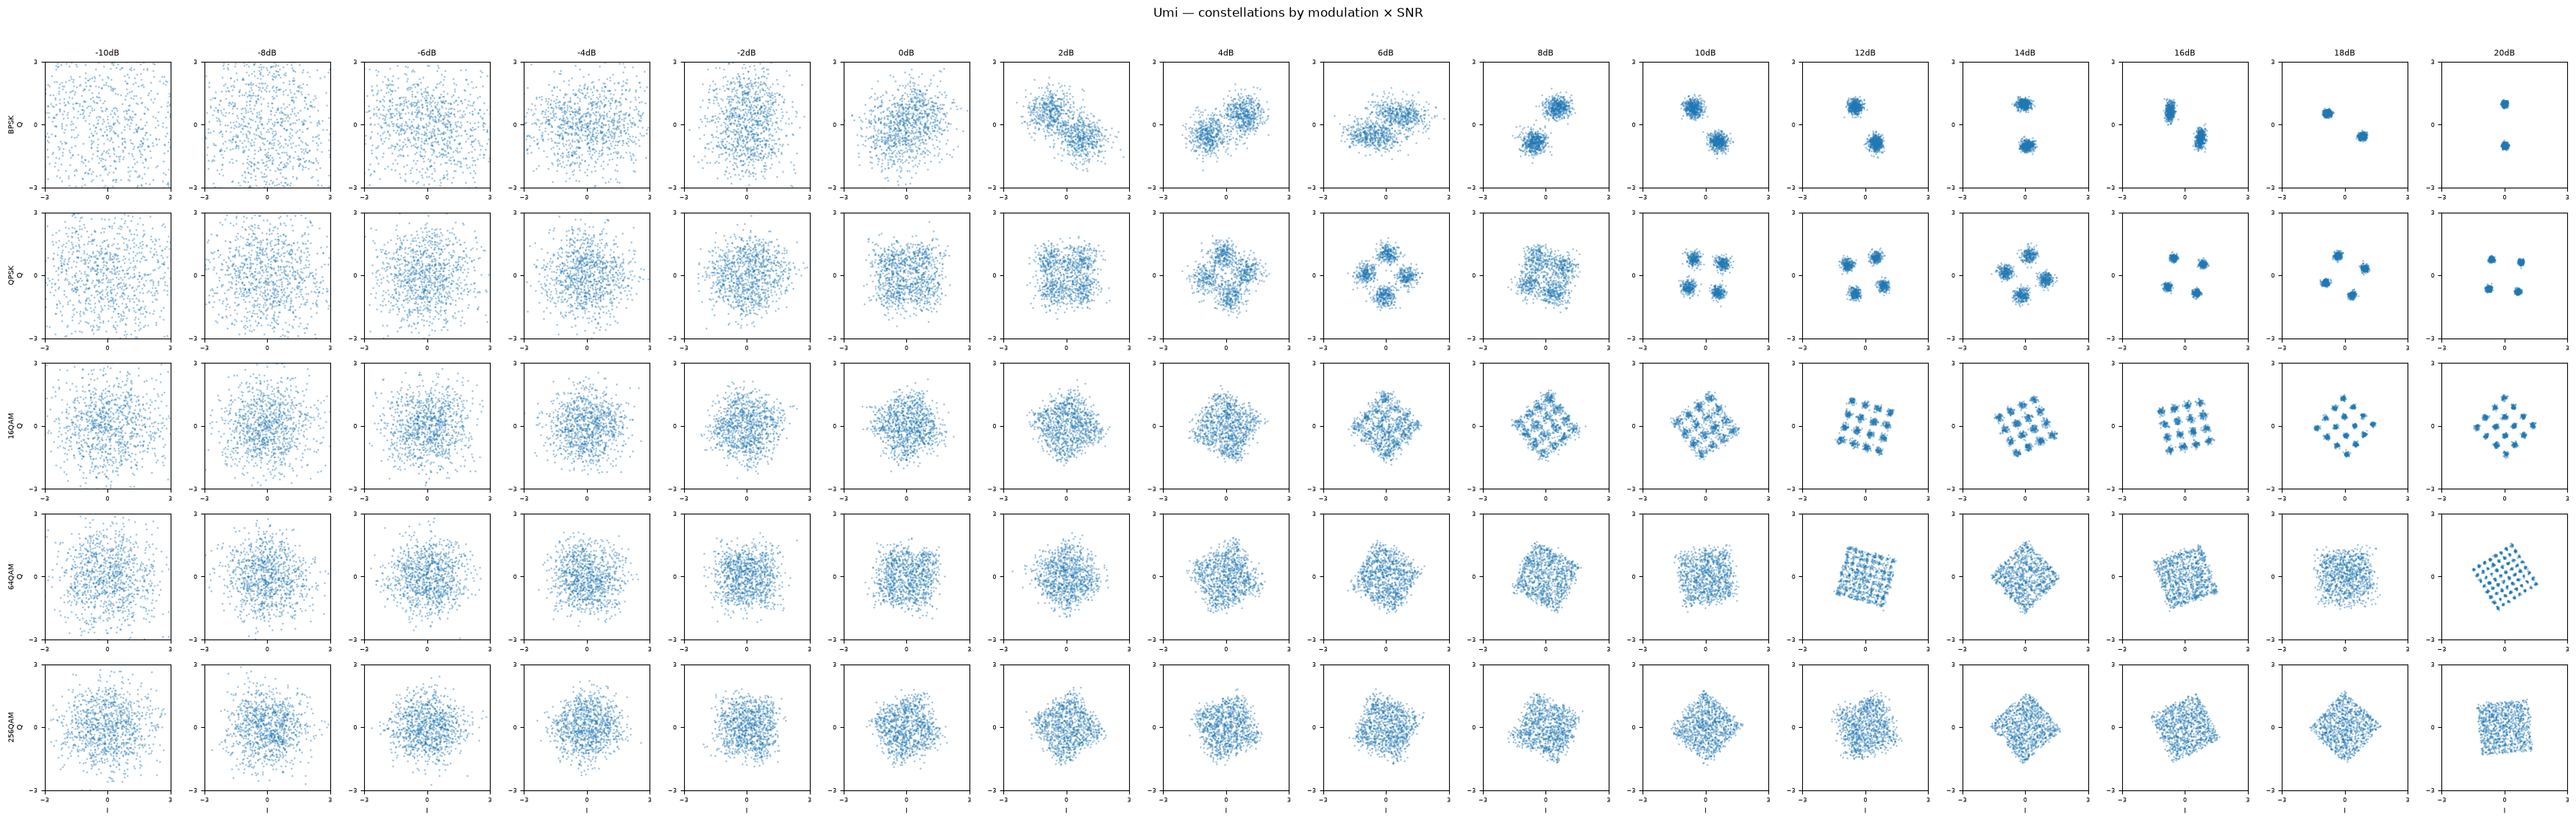

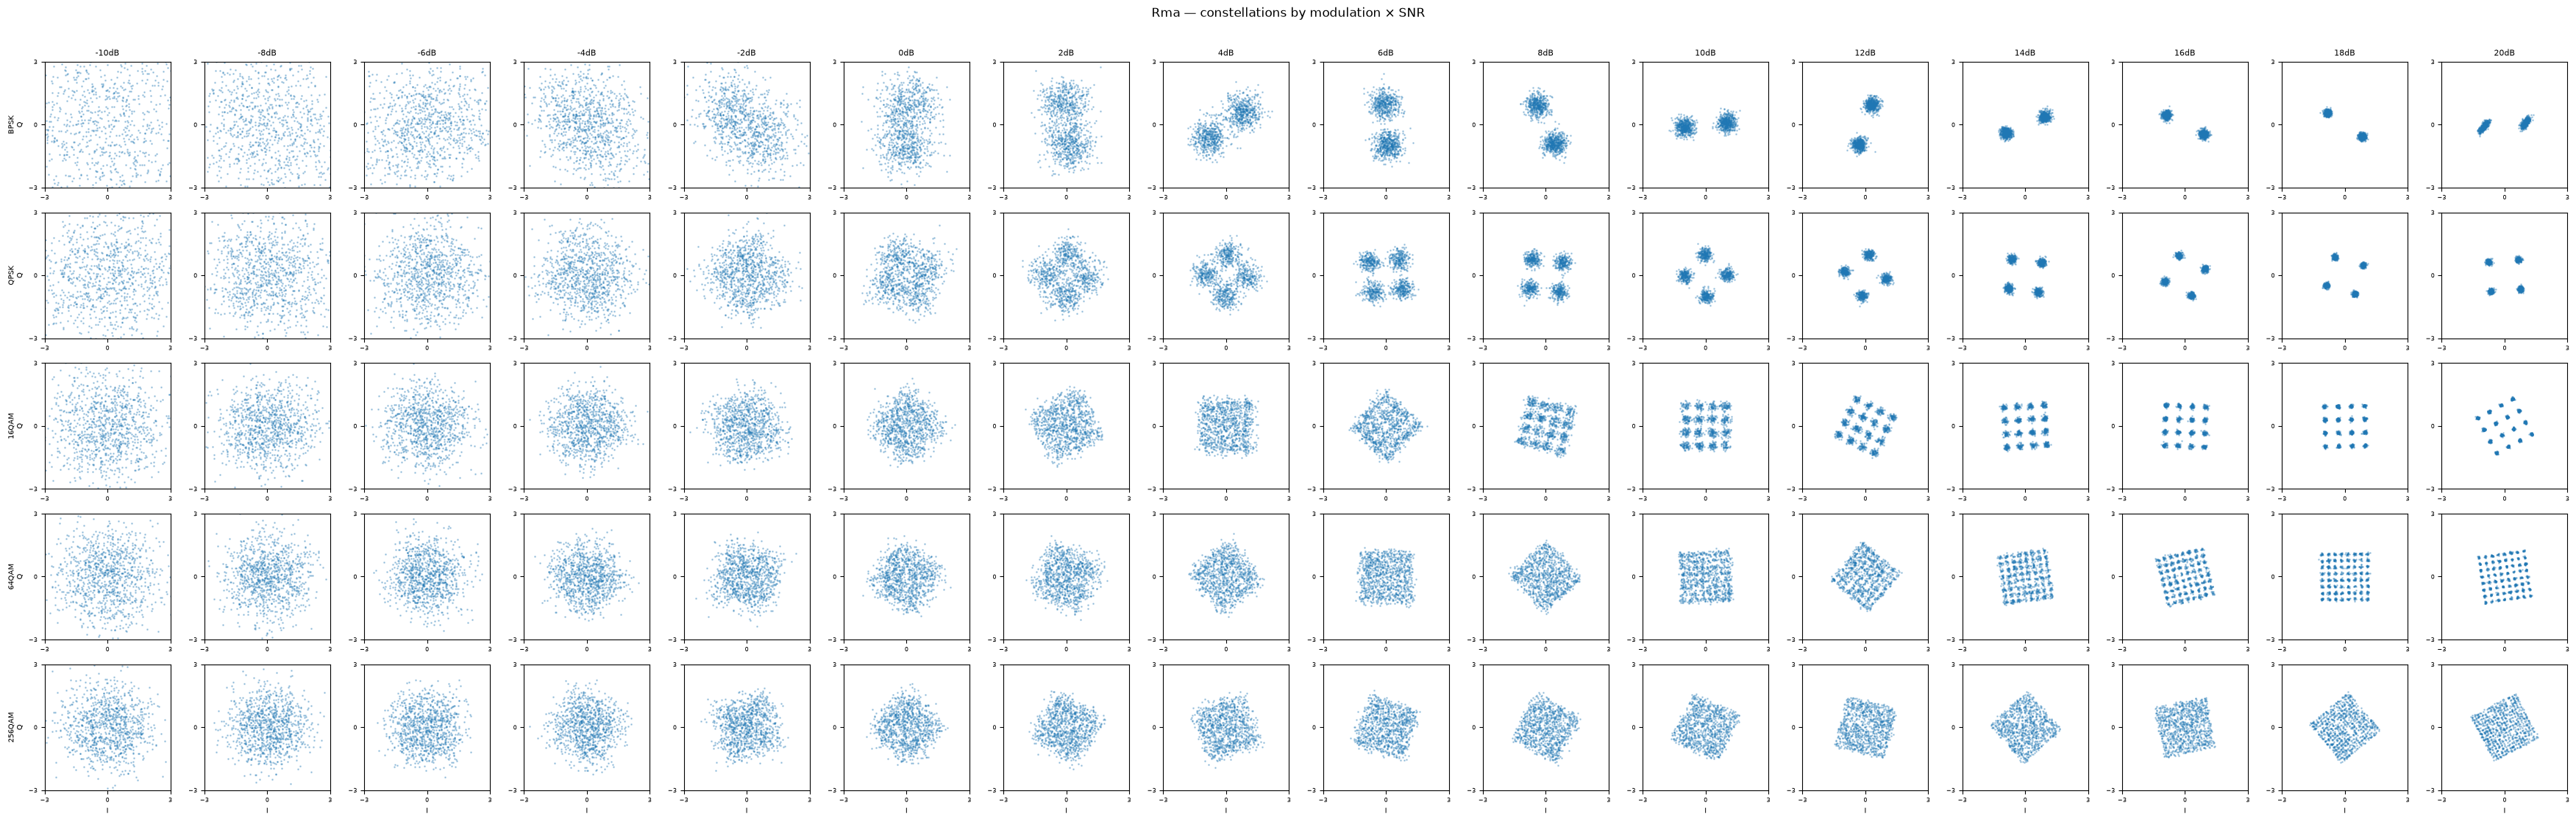

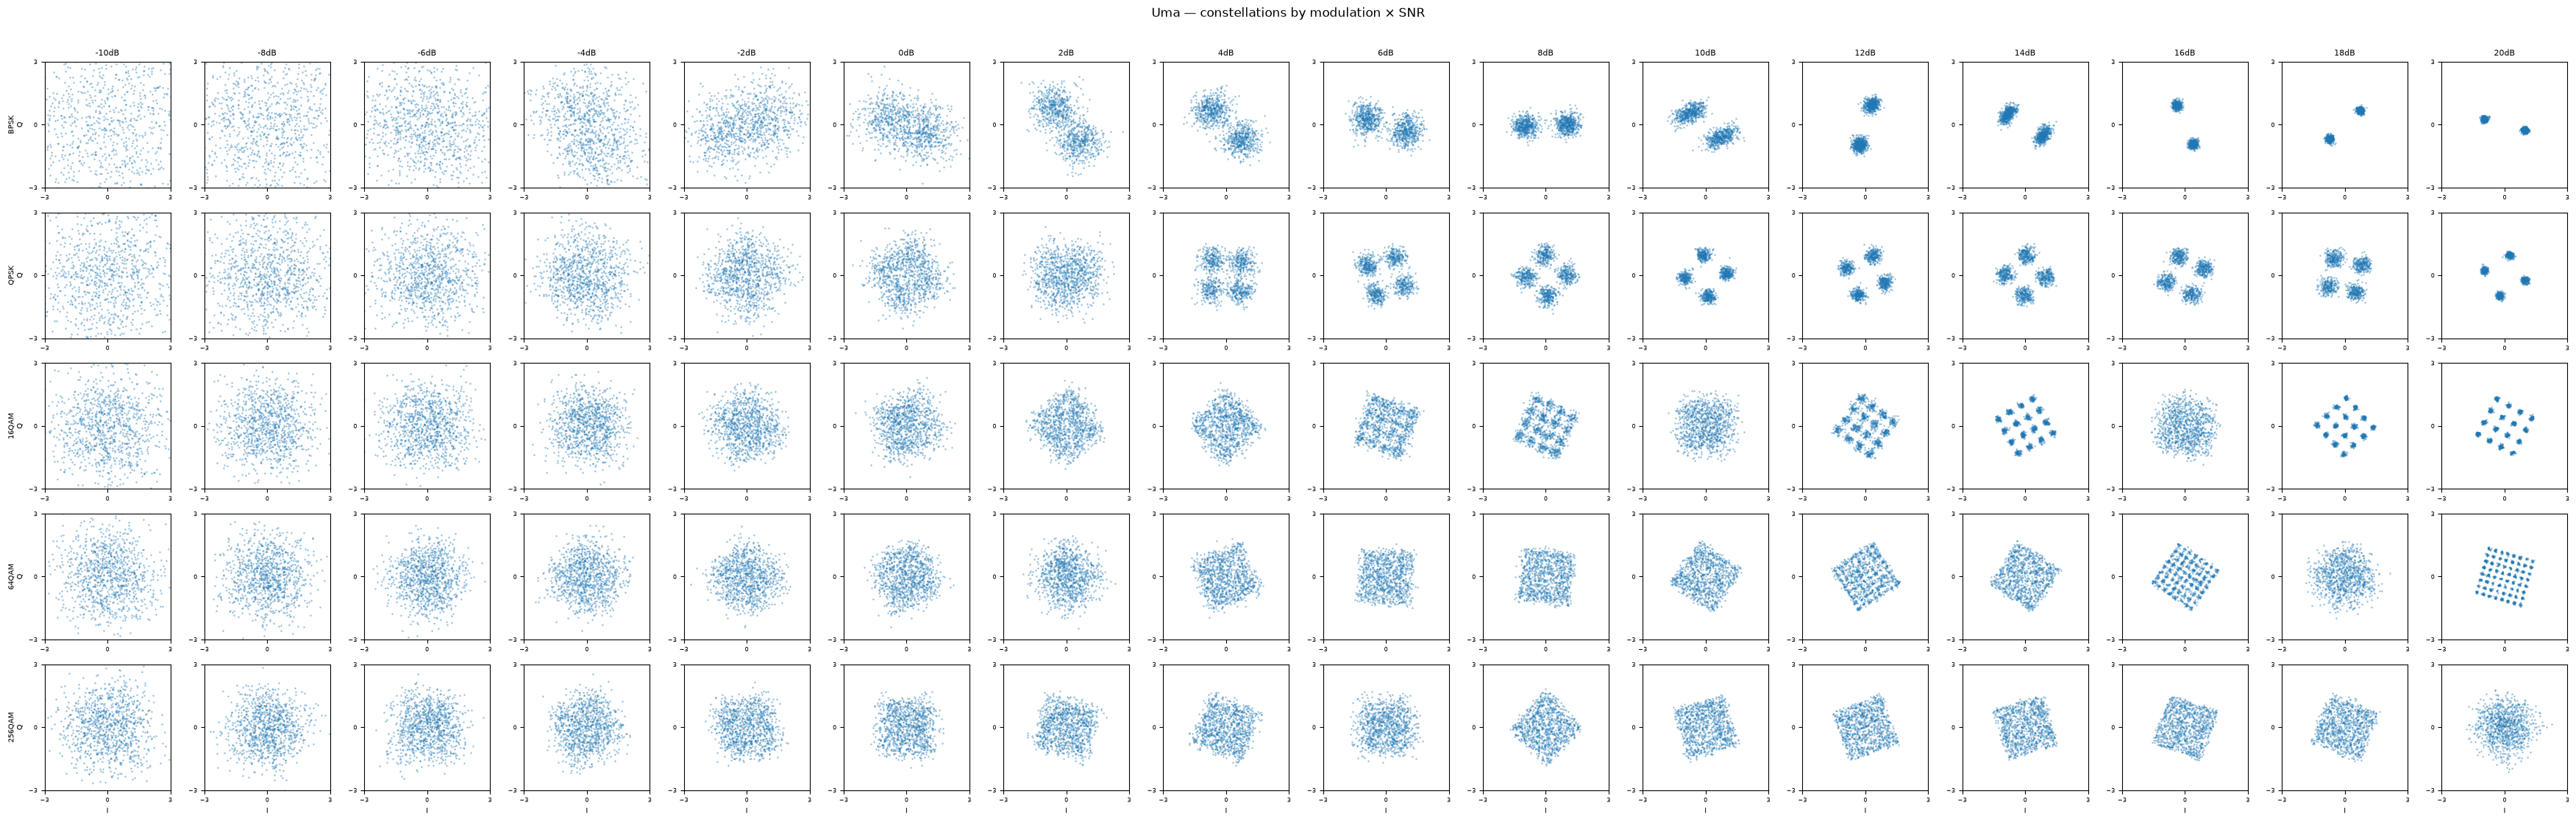

In [7]:
import matplotlib.pyplot as plt
import numpy as np

MOD_NAMES_CLEAN = ['BPSK', 'QPSK', '16QAM', '64QAM', '256QAM']

for label, clean_path in [('Umi', UMI_CLEAN_DIR), ('Rma', RMA_CLEAN_DIR), ('Uma', UMA_CLEAN_DIR)]:

    with h5py.File(clean_path, 'r') as f:
        data = f['Data'][:]
        mods = f['Mods'][:]
        snrs = f['SNRs'][:]

    snr_levels = np.unique(snrs)
    n_mods, n_snrs = len(MOD_NAMES_CLEAN), len(snr_levels)

    fig, axes = plt.subplots(n_mods, n_snrs, figsize=(2.2 * n_snrs, 2.2 * n_mods))
    fig.suptitle(f"{label} — constellations by modulation × SNR", y=1.01)

    for i, mod_name in enumerate(MOD_NAMES_CLEAN):
        mod_rows = mods[:, i] == 1

        for j, snr in enumerate(snr_levels):
            ax = axes[i, j]
            rows = mod_rows & (snrs == snr)

            sample = data[rows][0].flatten()
            ax.scatter(sample.real, sample.imag, s=1, alpha=0.3)

            ax.set_xlim(-3, 3)
            ax.set_ylim(-3, 3)
            ax.set_xticks([-3, 0, 3])
            ax.set_yticks([-3, 0, 3])
            ax.tick_params(labelsize=6)
            ax.set_aspect('equal')

            if i == 0:
                ax.set_title(f"{snr:.0f}dB", fontsize=8)
            if i == n_mods - 1:
                ax.set_xlabel('I', fontsize=7)
            if j == 0:
                ax.set_ylabel(f"{mod_name}\nQ", fontsize=7)

    plt.tight_layout()
    plt.show()

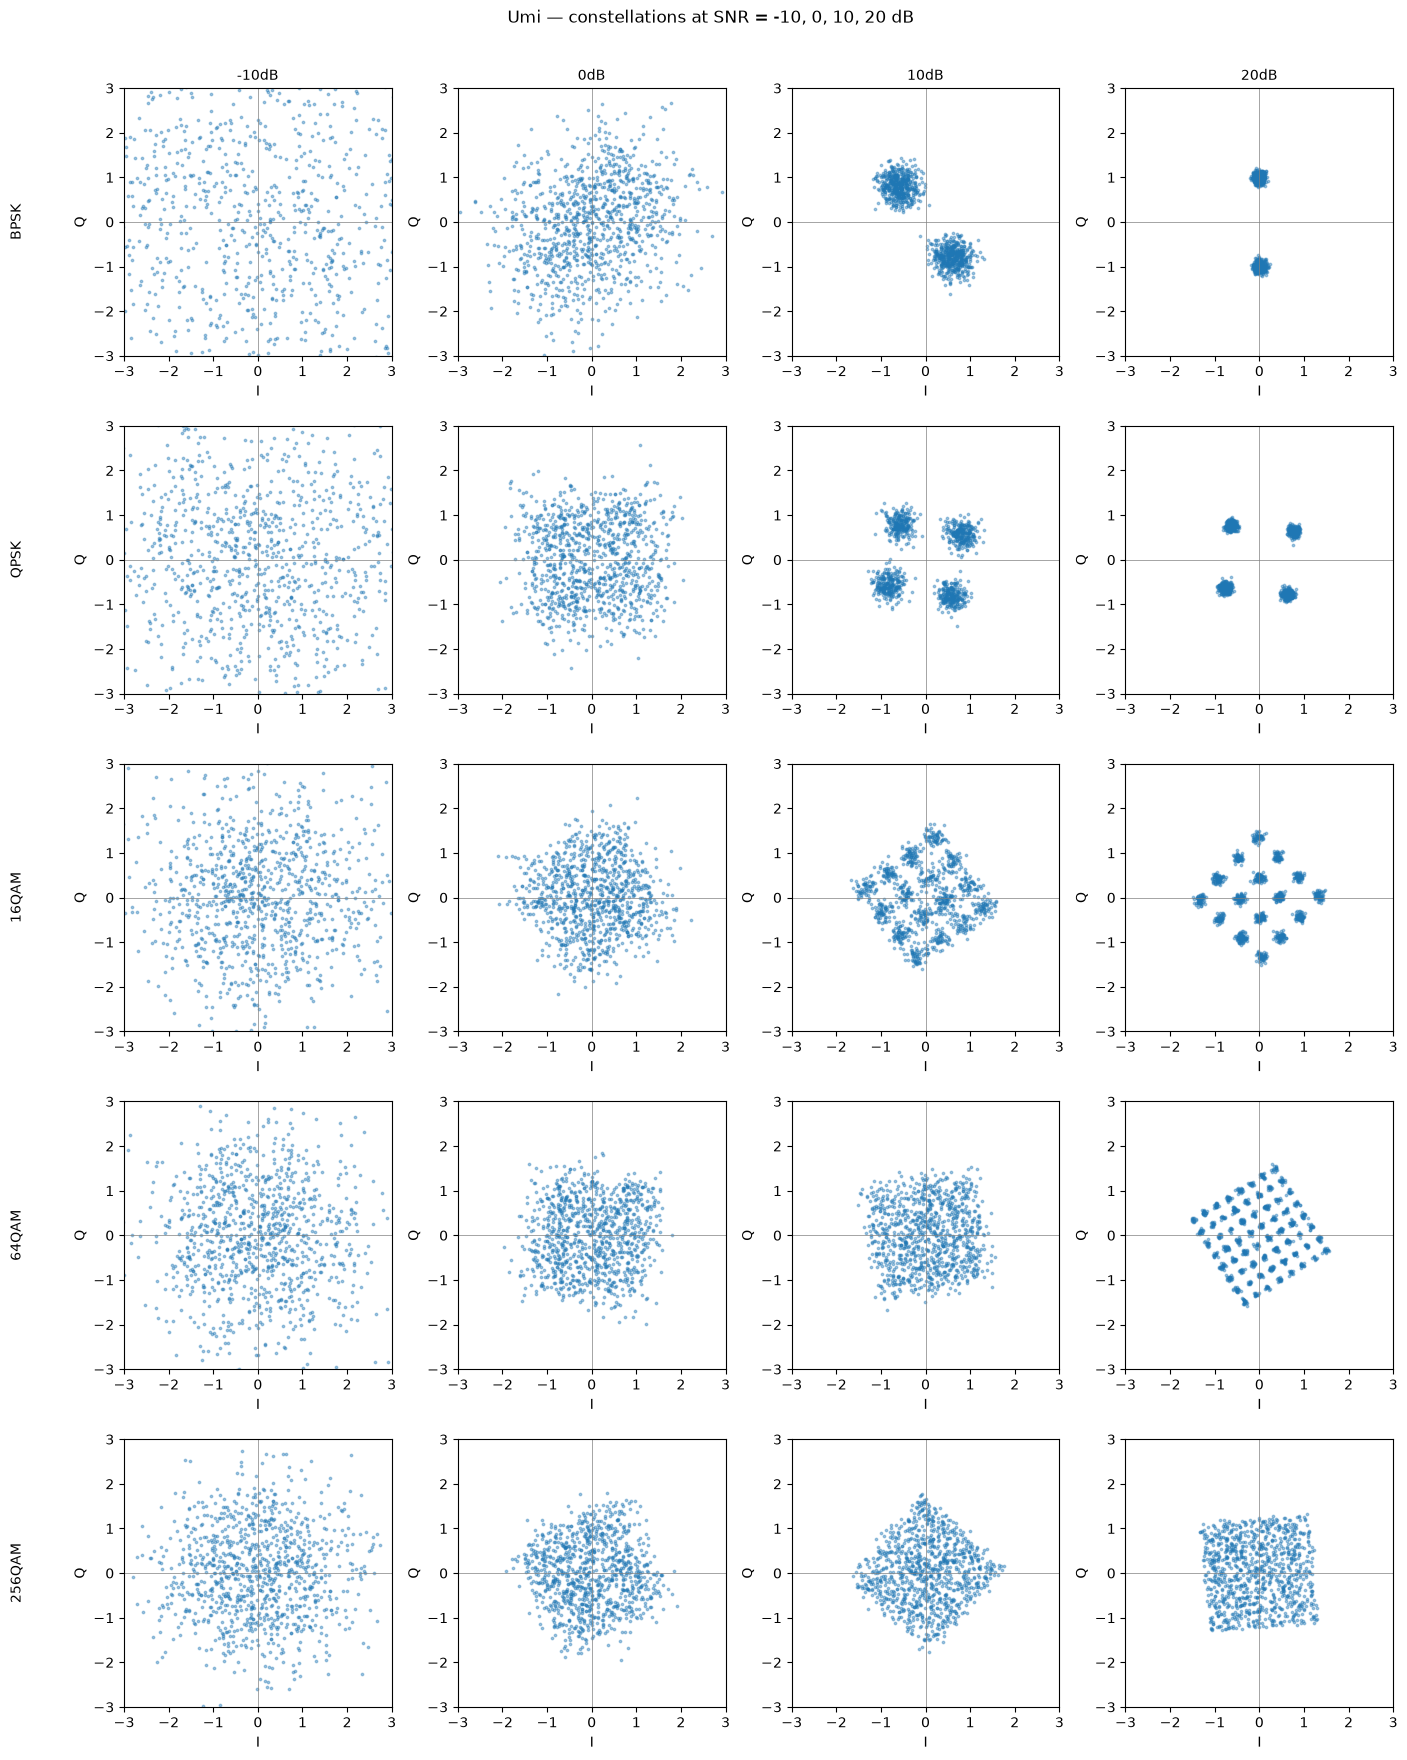

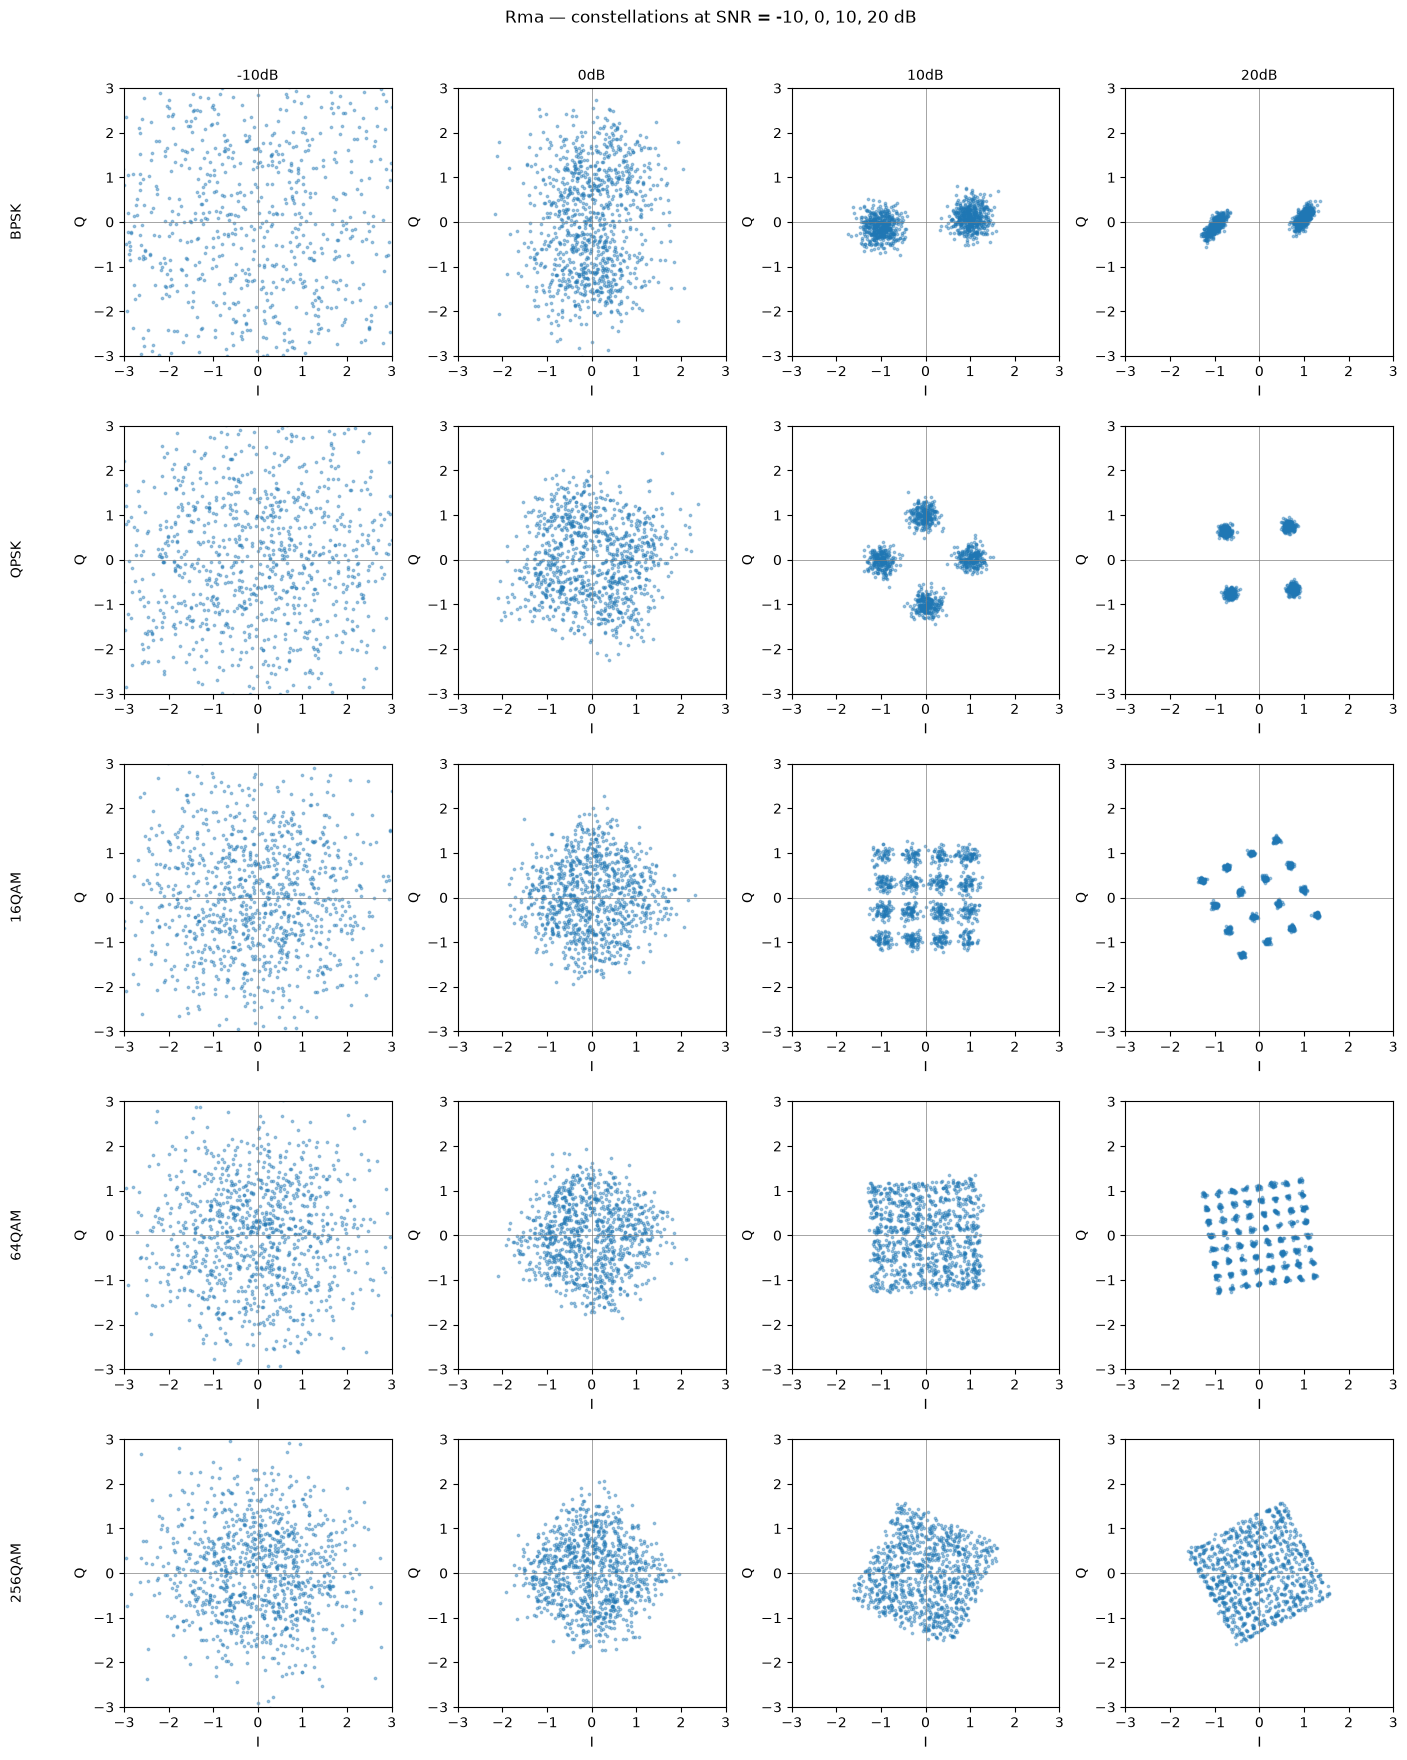

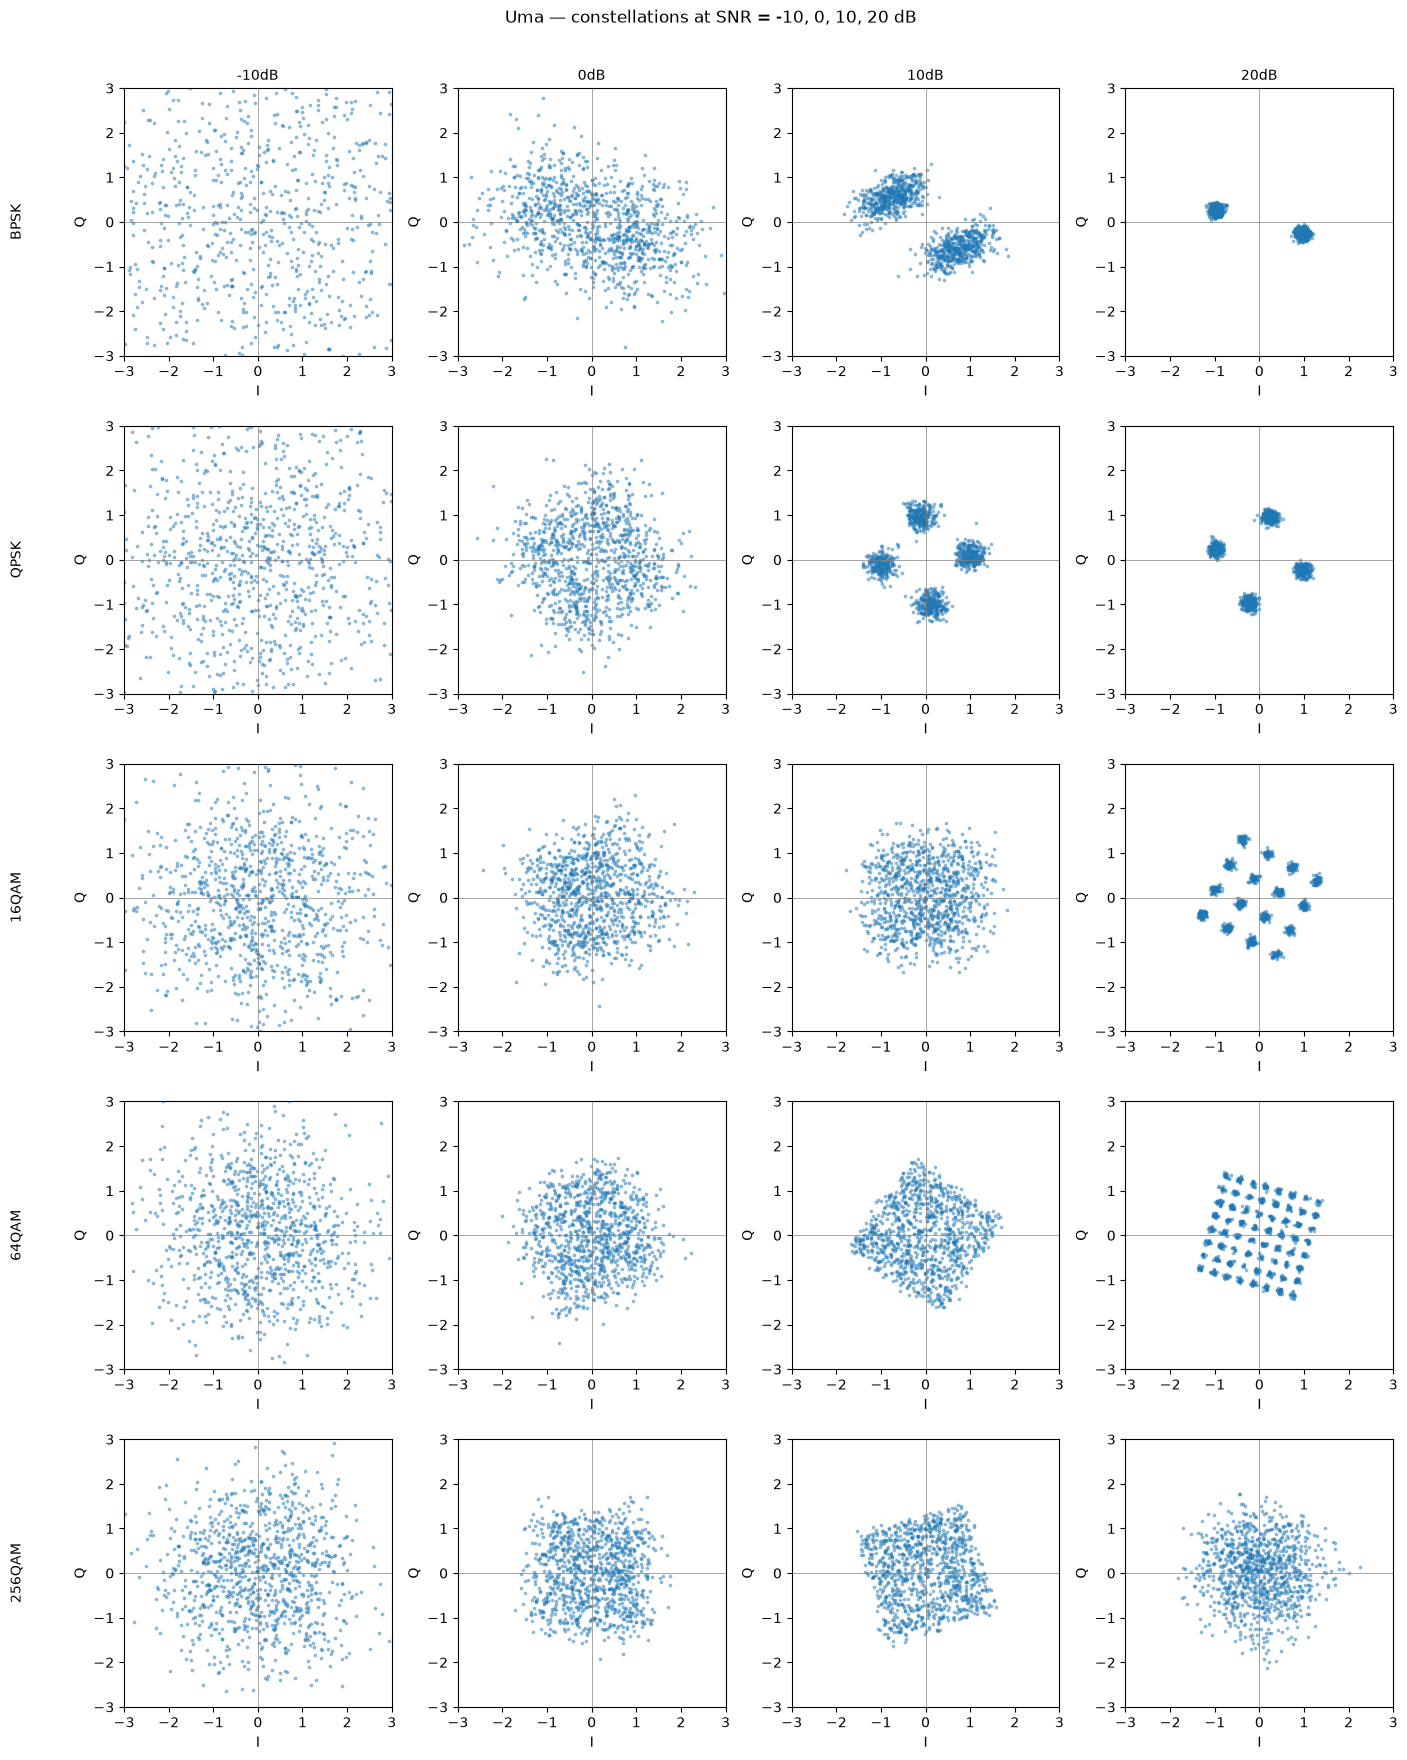

In [8]:
FOCUS_SNRS = [-10, 0, 10, 20]

for label, clean_path in [('Umi', UMI_CLEAN_DIR), ('Rma', RMA_CLEAN_DIR), ('Uma', UMA_CLEAN_DIR)]:

    with h5py.File(clean_path, 'r') as f:
        data = f['Data'][:]
        mods = f['Mods'][:]
        snrs = f['SNRs'][:]

    n_mods, n_snrs = len(MOD_NAMES_CLEAN), len(FOCUS_SNRS)

    fig, axes = plt.subplots(n_mods, n_snrs, figsize=(3.5 * n_snrs, 3.5 * n_mods))
    fig.suptitle(f"{label} — constellations at SNR = -10, 0, 10, 20 dB", y=1.005)

    for i, mod_name in enumerate(MOD_NAMES_CLEAN):
        mod_rows = mods[:, i] == 1

        for j, snr in enumerate(FOCUS_SNRS):
            ax = axes[i, j]
            rows = mod_rows & (snrs == snr)

            sample = data[rows][0].flatten()
            ax.scatter(sample.real, sample.imag, s=3, alpha=0.4)

            ax.set_xlim(-3, 3)
            ax.set_ylim(-3, 3)
            ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
            ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
            ax.set_xlabel('I')
            ax.set_ylabel('Q')
            ax.axhline(0, color='gray', lw=0.5)
            ax.axvline(0, color='gray', lw=0.5)
            ax.set_aspect('equal')

            if i == 0:
                ax.set_title(f"{snr}dB", fontsize=10)
            if j == 0:
                ax.text(-0.4, 0.5, mod_name, transform=ax.transAxes,
                         fontsize=10, rotation=90, va='center', ha='center')

    plt.tight_layout()
    plt.show()